In [1]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.216 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.5.20                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.15                          pyhcf101f3_0                  conda-forge                   
+ joblib                        1.5.3    

First 5 Rows:

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  floa

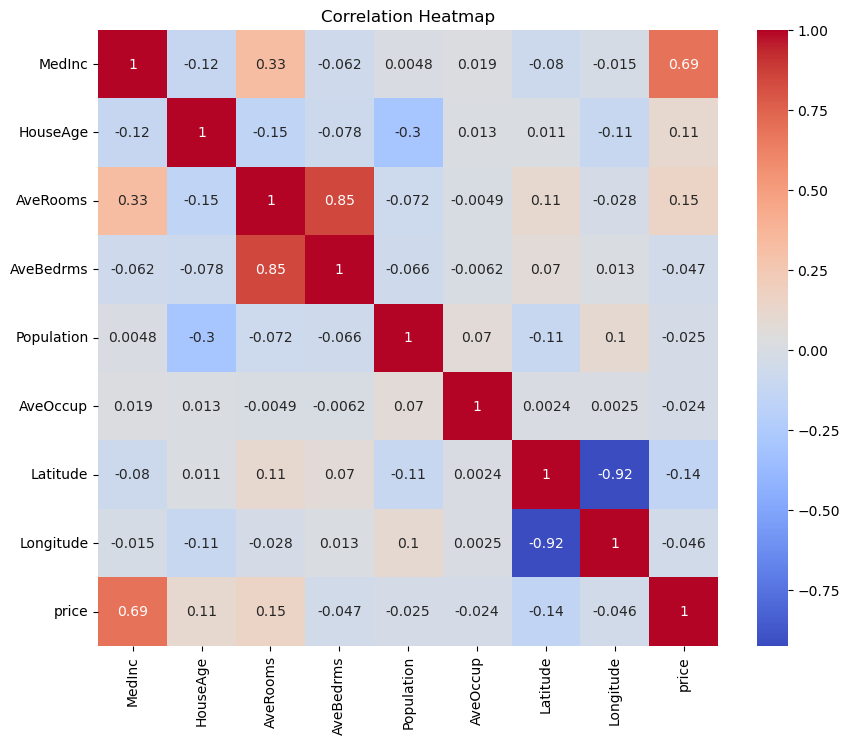

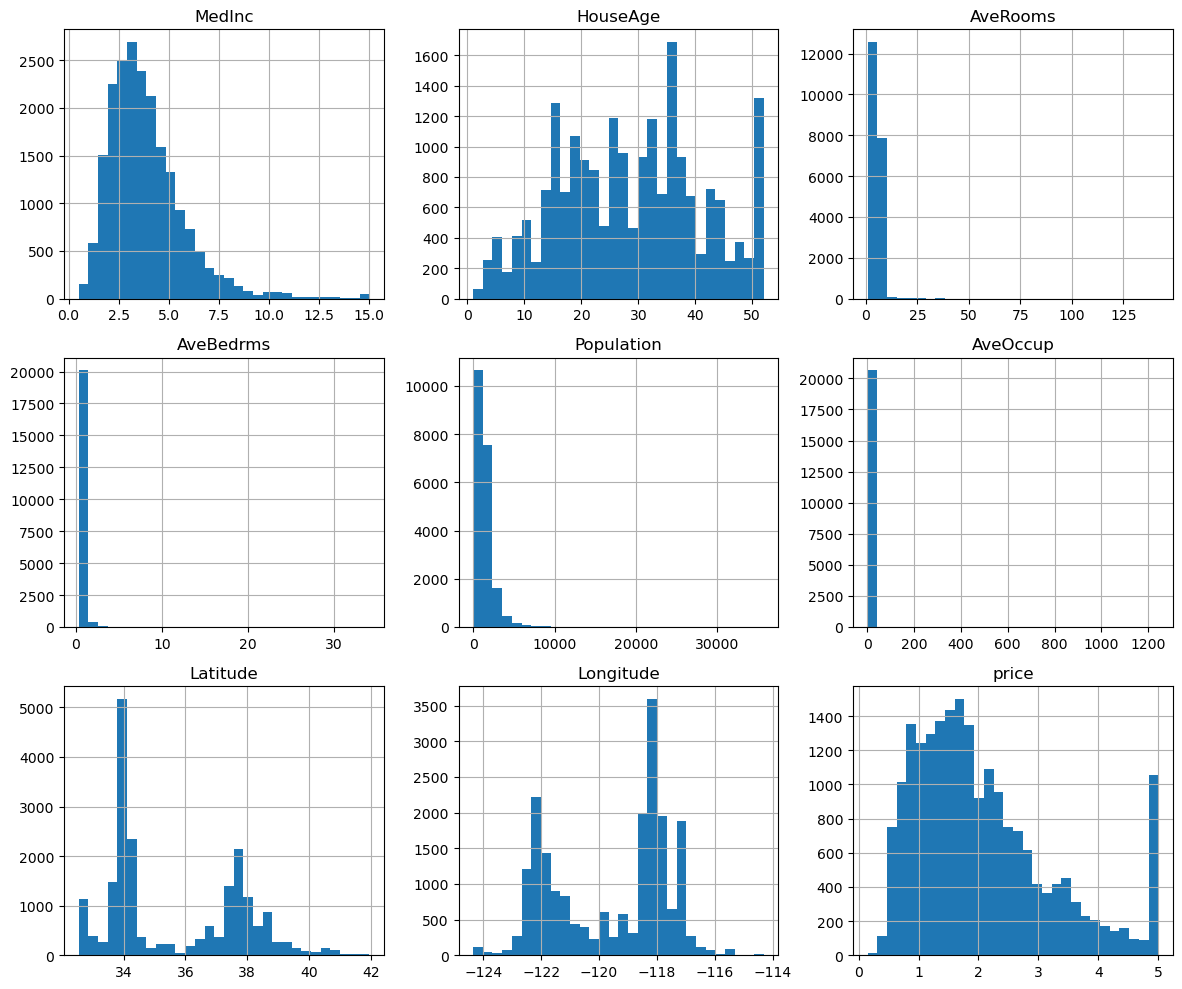


Training Data Shape : (16512, 8)
Testing Data Shape : (4128, 8)

MAE : 0.5332001304956555
RMSE : 0.7455813830127768
R2 Score : 0.5757877060324503


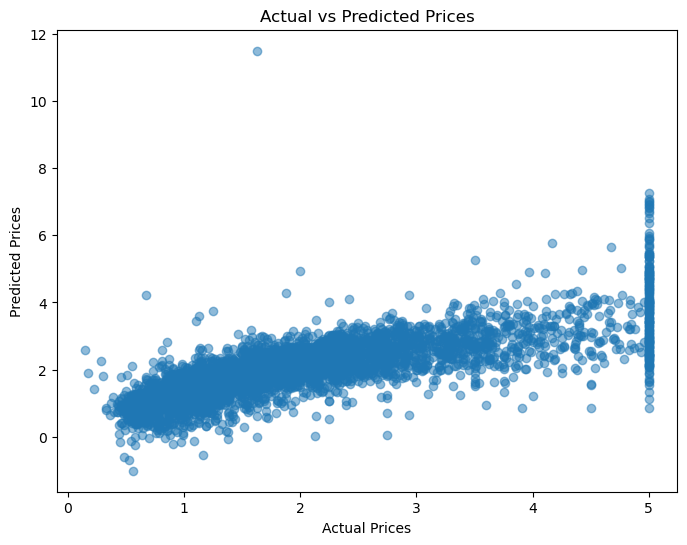

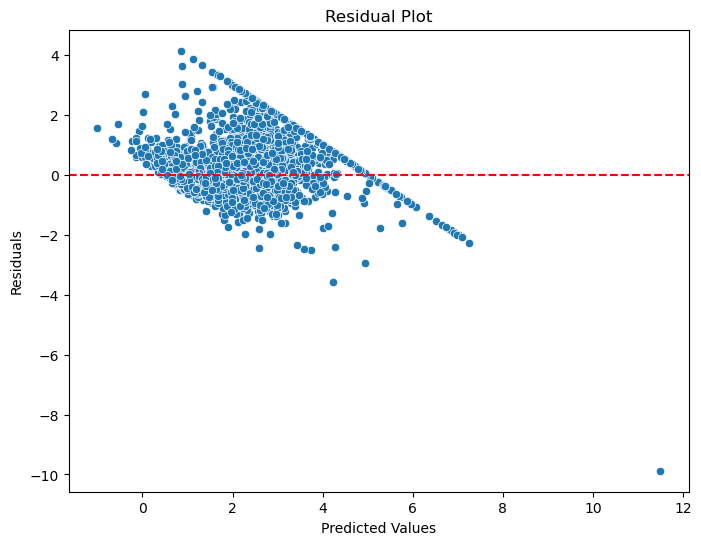


Feature Coefficients:

            Coefficient
MedInc         0.448675
HouseAge       0.009724
AveRooms      -0.123323
AveBedrms      0.783145
Population    -0.000002
AveOccup      -0.003526
Latitude      -0.419792
Longitude     -0.433708


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
#loading Dataset
housing = fetch_california_housing()
#converting to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

df['price'] = housing.target

print("First 5 Rows:\n")
print(df.head())

print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDataset Description:\n")
print(df.describe())
plt.figure(figsize=(10, 8))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

df.hist(figsize=(12, 10), bins=30)

plt.tight_layout()
plt.show()

X = df.drop('price', axis=1)

#Target
y = df['price']

#split Data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("\nTraining Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)

#plot
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("\nMAE :", mae)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE :", rmse)
r2 = r2_score(y_test, y_pred)
print("R2 Score :", r2)

#plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_pred,y=residuals)
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()
coeff_df = pd.DataFrame(model.coef_,X.columns,columns=['Coefficient'])

print("\nFeature Coefficients:\n")

print(coeff_df)